In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('/content/paises.csv', sep =';')
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,0.000,0.000,0.000
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,0.000,0.000,0.000


In [4]:
print(df.columns)

Index(['Country', 'Region', 'Population', 'Area (sq. mi.)',
       'Pop. Density (per sq. mi.)', 'Coastline (coast/area ratio)',
       'Net migration', 'Infant mortality (per 1000 births)',
       'GDP ($ per capita)', 'Literacy (%)', 'Phones (per 1000)', 'Arable (%)',
       'Crops (%)', 'Other (%)', 'Climate', 'Birthrate', 'Deathrate',
       'Agriculture', 'Industry', 'Service'],
      dtype='object')


Questao 1

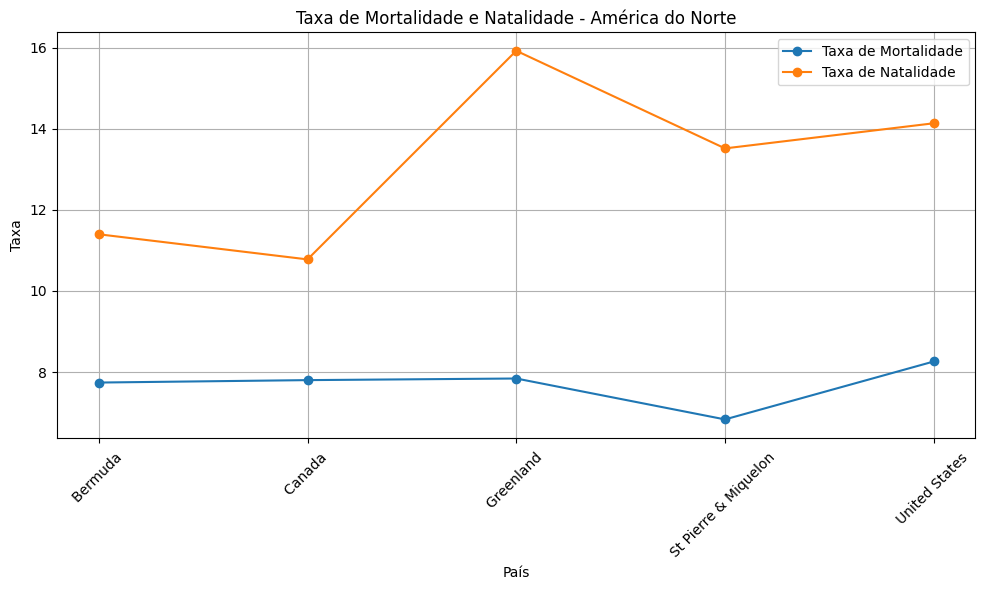

In [5]:
df_america_norte = df[df["Region"].str.strip() == "NORTHERN AMERICA"]
df_america_norte = df_america_norte.sort_values("Country")
plt.figure(figsize=(10, 6))
plt.plot(df_america_norte["Country"], df_america_norte["Deathrate"], marker='o', label="Taxa de Mortalidade")
plt.plot(df_america_norte["Country"], df_america_norte["Birthrate"], marker='o', label="Taxa de Natalidade")
plt.title("Taxa de Mortalidade e Natalidade - América do Norte")
plt.xlabel("País")
plt.ylabel("Taxa")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Questao 2

In [7]:
space = pd.read_csv('/content/space (3).csv', sep=';')
display(space.head())
print(space.columns)

,Num,Company Name,Location,Datum,Detail,Status Rocket,Cost,Status Mission
0,0,SpaceX,LC-39A Kennedy Space Center Florida USA,Fri Aug 07 2020 05:12 UTC,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,1,CASC,Site 9401 (SLS-2) Jiuquan Satellite Launch Cen...,Thu Aug 06 2020 04:01 UTC,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,SpaceX,Pad A Boca Chica Texas USA,Tue Aug 04 2020 23:57 UTC,Starship Prototype | 150 Meter Hop,StatusActive,0.00,Success
3,3,Roscosmos,Site 200/39 Baikonur Cosmodrome Kazakhstan,Thu Jul 30 2020 21:25 UTC,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,4,ULA,SLC-41 Cape Canaveral AFS Florida USA,Thu Jul 30 2020 11:50 UTC,Atlas V 541 | Perseverance,StatusActive,145.00,Success


Index(['Num', 'Company Name', 'Location', 'Datum', 'Detail', 'Status Rocket',
       ' Cost', 'Status Mission'],
      dtype='object')


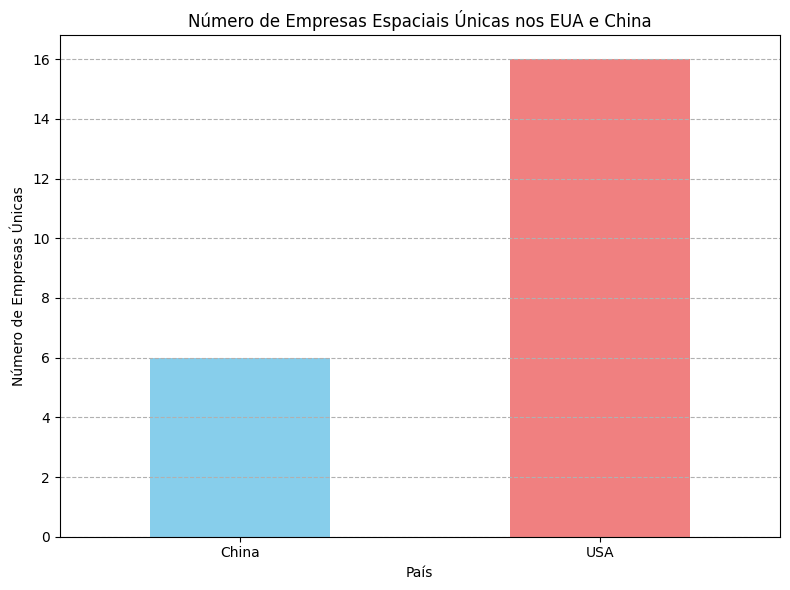

In [8]:
space['Country'] = space['Location'].apply(lambda x: x.split(' ')[-1])
space['Country'] = space['Country'].replace({'USA': 'USA', 'China': 'China', 'Kazakhstan': 'Kazakhstan', 'Russia': 'Russia', 'Japan': 'Japan', 'Iran': 'Iran', 'Brazil': 'Brazil', 'New': 'New Zealand', 'North': 'North Korea', 'South': 'South Korea'})
df_usa_china = space[space['Country'].isin(['USA', 'China'])]
company_counts = df_usa_china.groupby('Country')['Company Name'].nunique()
plt.figure(figsize=(8, 6))
company_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Número de Empresas Espaciais Únicas nos EUA e China')
plt.xlabel('País')
plt.ylabel('Número de Empresas Únicas')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

Ex 3

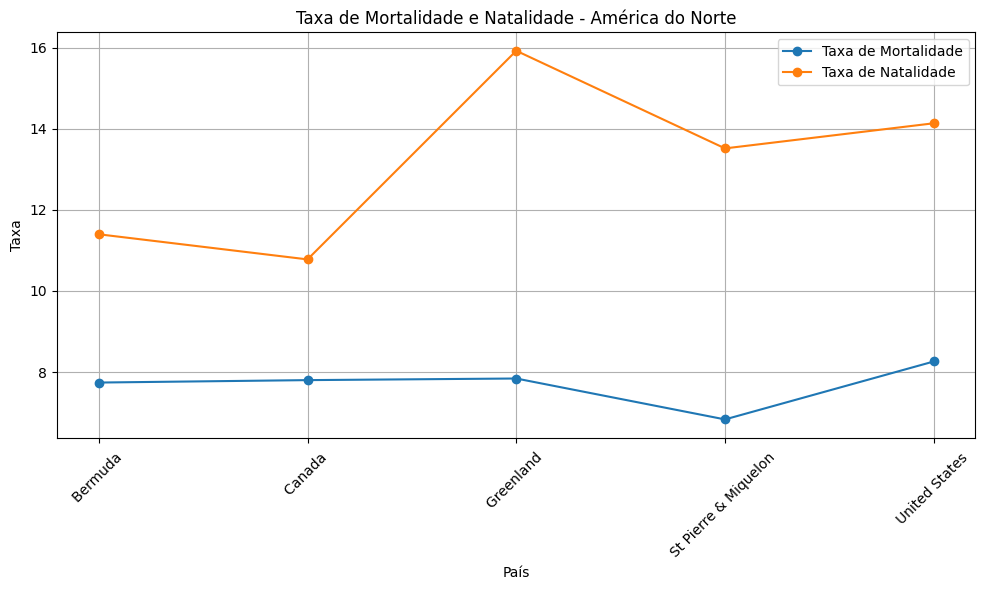

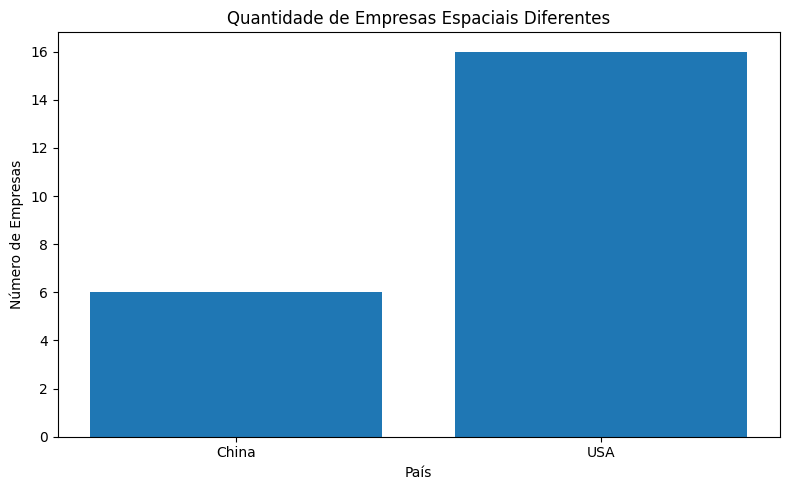

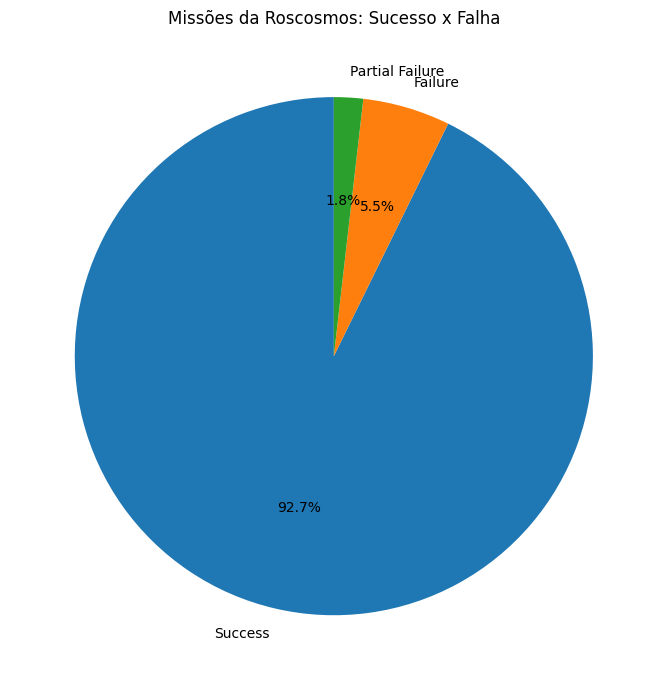

In [10]:
df_america_norte = df[df["Region"].str.strip() == "NORTHERN AMERICA"]
df_america_norte = df_america_norte.sort_values("Country")
plt.figure(figsize=(10, 6))
plt.plot(df_america_norte["Country"], df_america_norte["Deathrate"], marker='o', label="Taxa de Mortalidade")
plt.plot(df_america_norte["Country"], df_america_norte["Birthrate"], marker='o', label="Taxa de Natalidade")
plt.title("Taxa de Mortalidade e Natalidade - América do Norte")
plt.xlabel("País")
plt.ylabel("Taxa")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
space['Country'] = space['Location'].apply(lambda x: x.split(' ')[-1])
space['Country'] = space['Country'].replace({'USA': 'USA', 'China': 'China', 'Kazakhstan': 'Kazakhstan', 'Russia': 'Russia', 'Japan': 'Japan', 'Iran': 'Iran', 'Brazil': 'Brazil', 'New': 'New Zealand', 'North': 'North Korea', 'South': 'South Korea'})
df_usa_china_companies = space[space['Country'].isin(['USA', 'China'])]
contagem = df_usa_china_companies.groupby("Country")["Company Name"].nunique()
plt.figure(figsize=(8, 5))
plt.bar(contagem.index, contagem.values)
plt.title("Quantidade de Empresas Espaciais Diferentes")
plt.xlabel("País")
plt.ylabel("Número de Empresas")
plt.tight_layout()
plt.show()


df_roscosmos = space[space["Company Name"] == "Roscosmos"]
contagem_status = df_roscosmos["Status Mission"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(contagem_status.values, labels=contagem_status.index, autopct='%1.1f%%', startangle=90)
plt.title("Missões da Roscosmos: Sucesso x Falha")
plt.tight_layout()
plt.show()